In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('/content/encoded_df_final.csv')

df.select_dtypes(include=['number']).columns

Index(['WeekOfMonth', 'WeekOfMonthClaimed', 'Sex', 'Age', 'RepNumber',
       'DriverRating', 'FraudFound', 'Age2', 'age_gender'],
      dtype='object')

In [2]:
# 1. Prepare a subset for clustering demonstration (numerical features and a small sample)
np.random.seed(42) # for reproducibility
features = ['Age', 'WeekOfMonth', 'DriverRating']
df_sample = df[features].sample(n=100, random_state=42).reset_index(drop=True)


# 2. DBSCAN Demonstration: Scaling is crucial for distance-based algorithms
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_sample)
df_scaled = pd.DataFrame(df_scaled, columns=features)


In [16]:
# Apply DBSCAN
epsilon = 0.5
min_pts = 5
dbscan = DBSCAN(eps=epsilon, min_samples=min_pts)
df_sample['DBSCAN_Cluster'] = dbscan.fit_predict(df_scaled)

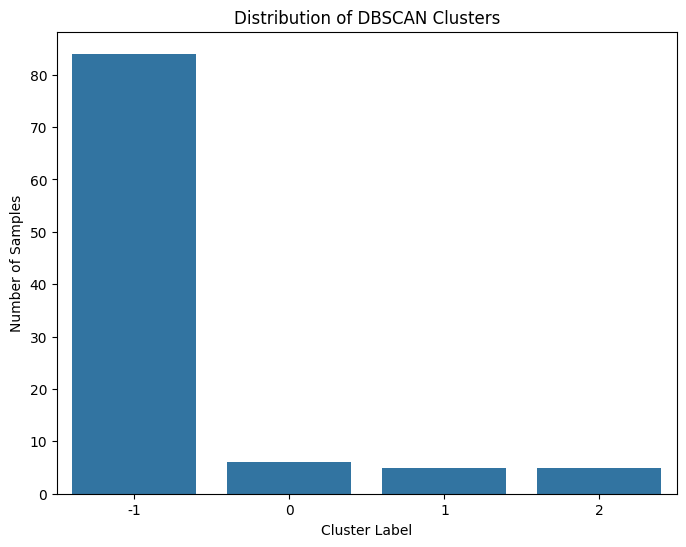

In [17]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='DBSCAN_Cluster', data=df_sample)
plt.title('Distribution of DBSCAN Clusters')
plt.xlabel('Cluster Label')
plt.ylabel('Number of Samples')
plt.show()

In [18]:
# 2. Define the parameter ranges
eps_values = [0.3, 0.5, 0.7, 1.0]
min_samples_values = [3, 5, 7, 10]

results = {}

for eps in eps_values:
    for min_pts in min_samples_values:
        key = f'e{eps}_m{min_pts}'
        dbscan = DBSCAN(eps=eps, min_samples=min_pts)
        labels = dbscan.fit_predict(df_scaled)
        results[key] = labels
df_results = pd.DataFrame(results)

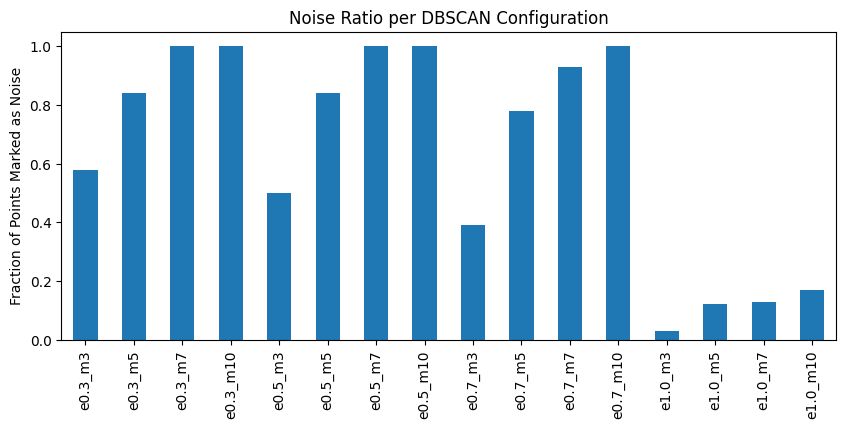

In [19]:
noise_ratio = (df_results == -1).mean()
noise_ratio.plot(kind='bar', figsize=(10,4), title='Noise Ratio per DBSCAN Configuration')
plt.ylabel('Fraction of Points Marked as Noise')
plt.show()


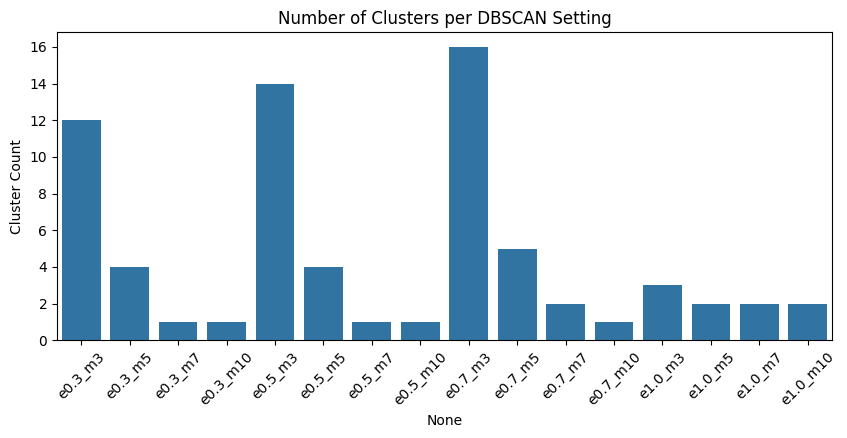

In [20]:
cluster_counts = df_results.apply(lambda x: len(set(x)) - (1 if -1 in x else 0))
cluster_counts.index = df_results.columns

plt.figure(figsize=(10,4))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values)
plt.xticks(rotation=45)
plt.title('Number of Clusters per DBSCAN Setting')
plt.ylabel('Cluster Count')
plt.show()


From this plot, we observed several key findings regarding how different combinations of epsilon and min_samples affect DBSCAN’s clustering behavior.
Smaller epsilon values and min_samples (for example, e0.3_m3) tended to produce a higher number of distinct clusters — in this case, 12 clusters. This suggests that with a smaller neighborhood radius and fewer points required to form a cluster, DBSCAN identified many small, dense regions within the data.
As epsilon increased, especially when min_samples remained small (such as e1.0_m3), the number of clusters generally decreased — for instance, from 12 clusters at e0.3_m3 down to 3 at e1.0_m3. This occurs because a larger epsilon expands the neighborhood radius, allowing points that are further apart to be considered neighbors. Consequently, smaller clusters merge into fewer, larger ones.

For a fixed epsilon, increasing min_samples also led to a reduction in the number of clusters. For example, with epsilon fixed at 0.3, increasing min_samples from 3 to 5, 7, and 10 reduced the cluster count from 12 to 4, 1, and 1 respectively. A higher min_samples value raises the density threshold needed to form a cluster, causing DBSCAN to classify more points as noise or merge nearby clusters that no longer meet the density requirement.

In extreme cases, such as e0.3_m7, e0.3_m10, e0.5_m7, e0.5_m10, and e0.7_m10, the algorithm produced only one cluster. When viewed alongside the “Noise Ratio per DBSCAN Configuration” plot, these cases suggest that overly strict parameters caused most or all points to be labeled as noise, leaving only a trivial cluster or none at all.

Overall, the plot visually demonstrates the trade-off between identifying many small, dense clusters and fewer, broader clusters. It highlights DBSCAN’s sensitivity to parameter selection and the importance of tuning epsilon and min_samples for meaningful results.

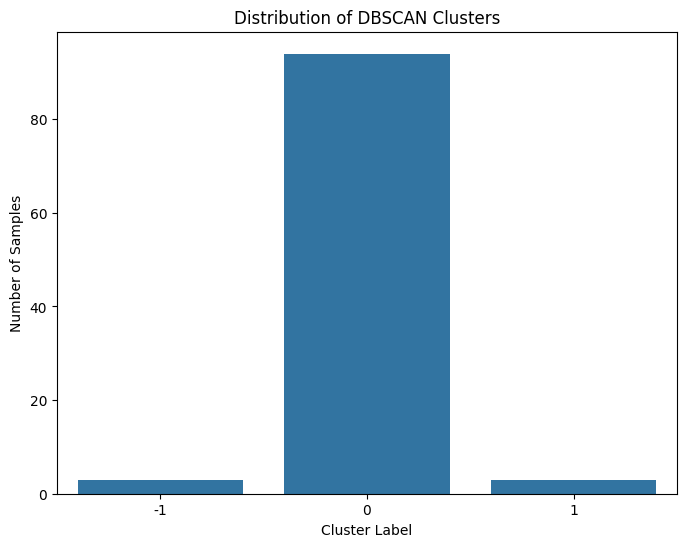

In [3]:
epsilon = 1
min_pts = 3
dbscan = DBSCAN(eps=epsilon, min_samples=min_pts)
df_sample['DBSCAN_Cluster'] = dbscan.fit_predict(df_scaled)

import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='DBSCAN_Cluster', data=df_sample)
plt.title('Distribution of DBSCAN Clusters')
plt.xlabel('Cluster Label')
plt.ylabel('Number of Samples')
plt.show()

Text(0, 0.5, 'Driver Rating')

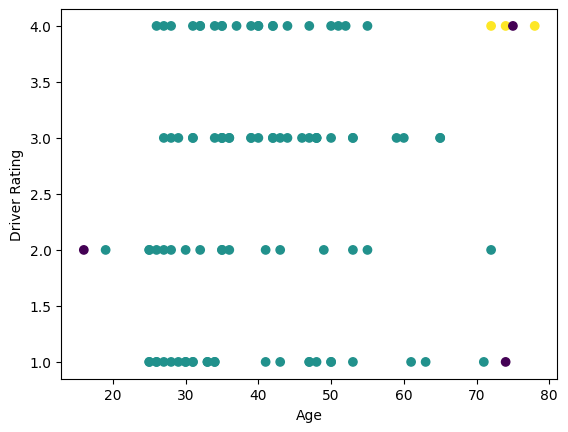

In [7]:
plt.scatter(
    df_sample['Age'],
    df_sample['DriverRating'],
    c=df_sample['DBSCAN_Cluster']
)
plt.xlabel('Age')
plt.ylabel('Driver Rating')

The scatter plot generated above visualizes the DBSCAN clusters using the features Age and DriverRating, with parameters epsilon = 1 and min_samples = 3. Each point in the plot corresponds to an observation from df_sample, and its color indicates the cluster assigned by DBSCAN. With these parameters, DBSCAN identifies several clusters, each represented by a different color on the plot. These clusters appear as dense groupings of points where the algorithm detected sufficient local density. Points that are not part of any dense region are labeled as noise (cluster -1) and typically appear as isolated or differently colored points scattered away from the main clusters.

This visualization also helps reveal how Age and DriverRating relate within each cluster. For instance, some clusters might reflect younger drivers with lower ratings, while others may represent older drivers with higher ratings. You may also see clusters where values of both features vary more widely but still form dense regions that DBSCAN considers meaningful.
Overall, the plot provides a clear view of how DBSCAN segments the data in the Age vs. DriverRating space, offering insight into potential behavioral patterns or customer segments based on the density structure uncovered by the algorithm.

### Comparing Different Linkage Methods for HAC

Different linkage methods calculate the 'distance' between clusters in various ways, leading to potentially different dendrogram structures and cluster formations. Let's visualize a few common methods:

-   **Ward:** Minimizes the variance of the clusters being merged.
-   **Single:** Uses the minimum distance between observations in any two clusters.
-   **Complete:** Uses the maximum distance between observations in any two clusters.
-   **Average:** Uses the average distance between all observations in any two clusters.


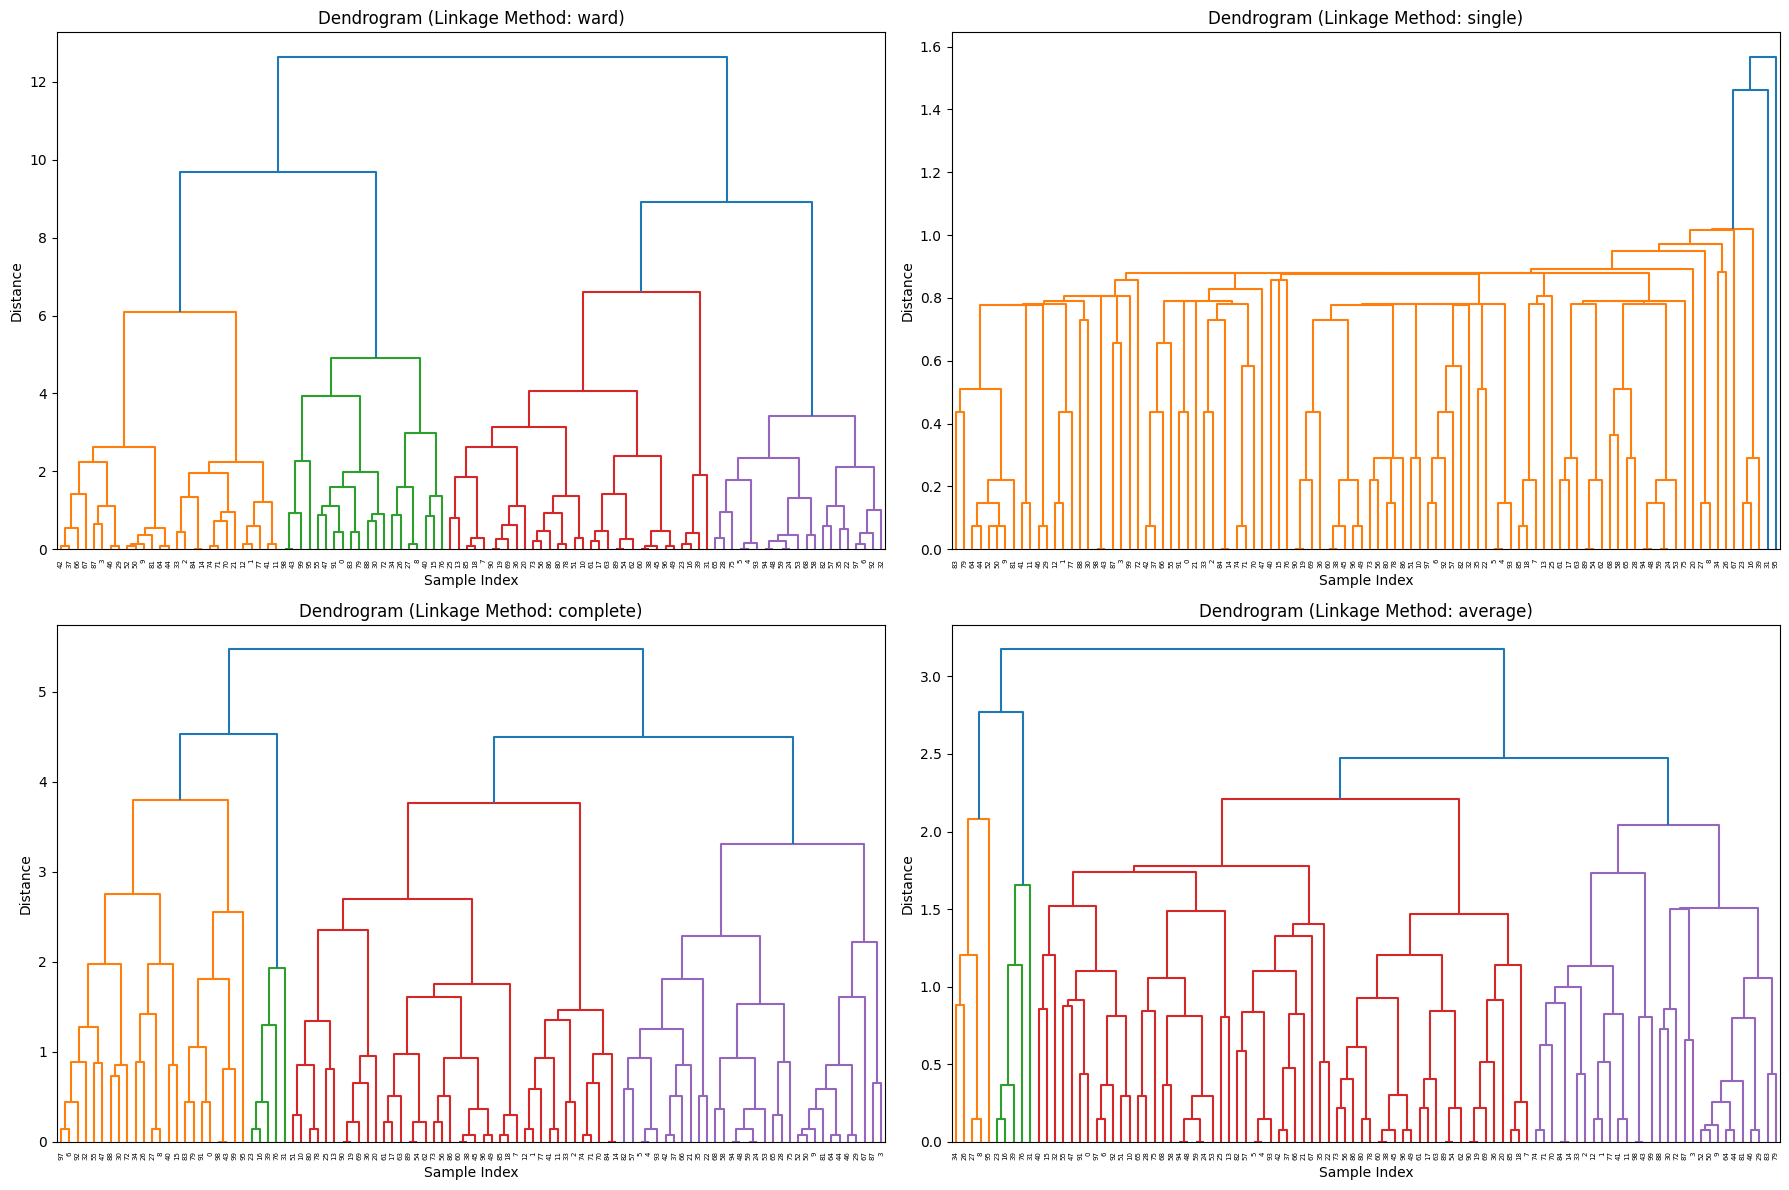

In [12]:
linkage_methods = ['ward', 'single', 'complete', 'average']

plt.figure(figsize=(18, 12))

for i, method in enumerate(linkage_methods):
    plt.subplot(2, 2, i + 1) # Create a 2x2 grid of plots
    linked = linkage(df_scaled, method=method, metric='euclidean')
    dendrogram(linked,
               orientation='top',
               distance_sort='descending',
               show_leaf_counts=False)
    plt.title(f'Dendrogram (Linkage Method: {method})')
    plt.xlabel('Sample Index')
    plt.ylabel('Distance')

plt.tight_layout()
plt.show()

### Analyzing HAC Clusters

Now that we've visualized the dendrograms for different linkage methods, let's extract the actual cluster assignments for each method. We'll use the `fcluster` function to cut the dendrogram, aiming to create 3 clusters for each method for comparison. After obtaining the cluster labels, we'll examine the size and distribution of samples within these clusters and visualize them using a scatter plot.

In [13]:
from scipy.cluster.hierarchy import fcluster
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_scaled and linkage_methods are already defined from previous steps

hac_results = {}
for method in linkage_methods:
    # Recalculate linked for each method since 'linked' was overwritten in the loop
    linked = linkage(df_scaled, method=method, metric='euclidean')

    # Cut tree to form 3 clusters for comparison
    # 'maxclust' criterion cuts to form a specified number of clusters
    clusters = fcluster(linked, t=3, criterion='maxclust')
    hac_results[f'HAC_{method}_clusters'] = clusters

# Create a DataFrame to store cluster assignments
df_hac_clusters = pd.DataFrame(hac_results, index=df_sample.index)

# Combine with original sample data for visualization
df_sample_with_hac = pd.concat([df_sample, df_hac_clusters], axis=1)

print("Distribution of samples across clusters for each linkage method (3 clusters):")
for col in df_hac_clusters.columns:
    print(f"\n{col}:")
    print(df_hac_clusters[col].value_counts().sort_index())


Distribution of samples across clusters for each linkage method (3 clusters):

HAC_ward_clusters:
HAC_ward_clusters
1    53
2    20
3    27
Name: count, dtype: int64

HAC_single_clusters:
HAC_single_clusters
1    98
2     1
3     1
Name: count, dtype: int64

HAC_complete_clusters:
HAC_complete_clusters
1    72
2     5
3    23
Name: count, dtype: int64

HAC_average_clusters:
HAC_average_clusters
1    90
2     5
3     5
Name: count, dtype: int64


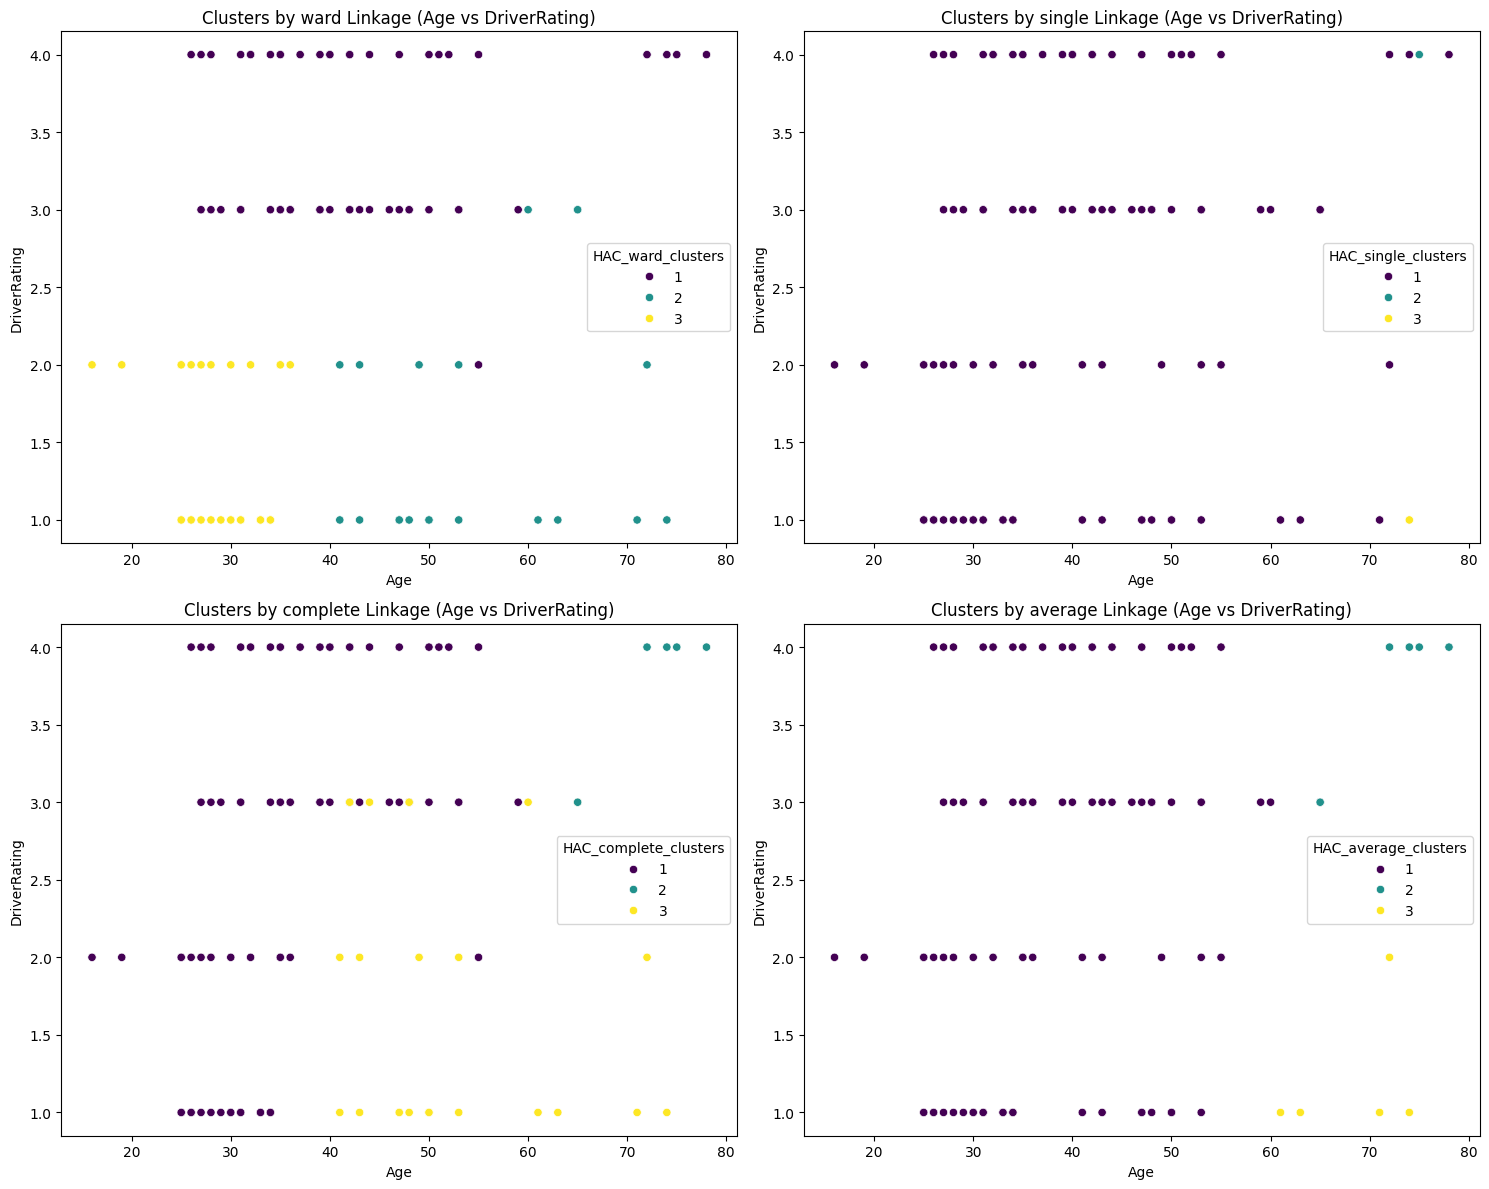

In [14]:
# Visualization: Scatter plots for Age vs DriverRating, colored by cluster

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))
axes = axes.flatten()

# Choose two features for the scatter plot to visualize clusters
features_to_plot = ['Age', 'DriverRating']

for i, method in enumerate(linkage_methods):
    ax = axes[i]
    cluster_col = f'HAC_{method}_clusters'
    sns.scatterplot(x=features_to_plot[0], y=features_to_plot[1], hue=cluster_col,
                    data=df_sample_with_hac, palette='viridis', legend='full', ax=ax)
    ax.set_title(f'Clusters by {method} Linkage ({features_to_plot[0]} vs {features_to_plot[1]})')
    ax.set_xlabel(features_to_plot[0])
    ax.set_ylabel(features_to_plot[1])

plt.tight_layout()
plt.show()


The scatter plots visualizing ‘Age’ vs ‘DriverRating’ for each Hierarchical Agglomerative Clustering (HAC) linkage method reveal distinct clustering behaviors across techniques.

**Ward Linkage (Top-Left Plot):**
This plot displays the most balanced and visually distinct clusters. The three clusters, shown in different colors, are well-separated and approximately spherical. Since Ward linkage minimizes variance within clusters, it often produces compact, evenly sized groups when viewed in two dimensions. The clusters occupy distinct regions in the ‘Age’ and ‘DriverRating’ space, suggesting meaningful segmentation of drivers based on these features.


**Single Linkage (Top-Right Plot):**
The single linkage method exhibits the classic “chaining effect,” where one large cluster dominates while the remaining clusters are tiny and often contain only one or two points (as indicated by the counts: 98, 1, 1). Visually, the plot is mostly one color with a few isolated points representing small clusters. Because single linkage connects clusters based on the closest pair of points, it is highly sensitive to noise and can form elongated or poorly separated groups.

**Complete Linkage (Bottom-Left Plot):**
Complete linkage produces more compact and well-defined clusters compared to single or average linkage, as it merges clusters based on the maximum distance between points. Although there is still some imbalance in cluster size (72, 5, 23), the resulting clusters are generally cohesive and visually distinct. This method tends to form smaller, tighter clusters that are clearly separated, though one cluster may still dominate in size.


**Average Linkage (Bottom-Right Plot):**
Average linkage serves as a middle ground between single and complete linkage. While it shows some imbalance (90, 5, 5), its clusters are better separated and more resistant to noise than those from single linkage. The clusters are moderately compact without the strong spherical tendency of complete linkage. As a result, the separation is visually improved, though not as pronounced as with Ward linkage.
In summary, the scatter plots highlight how the choice of linkage method significantly impacts the shape, size, and separation of clusters when projected onto ‘Age’ and ‘DriverRating’. Among the methods, Ward linkage provides the most intuitively meaningful and balanced clustering, while single linkage demonstrates its tendency to form one large, poorly separated cluster.


# Task
Fix the `SyntaxError` in the `plt.scatter` function call by moving `c=df_sample['DBSCAN_Cluster']` outside the square brackets to be a separate keyword argument, and then execute the corrected code to display the scatter plot.

## Fix Syntax Error

### Subtask:
Correct the `plt.scatter` function call by moving the `c=df_sample['DBSCAN_Cluster']` argument outside the square brackets of the y-axis data, making it a separate keyword argument to the scatter function.


**Reasoning**:
The previous code block had a SyntaxError in the `plt.scatter` function call. I need to correct it by placing the `c` argument outside the square brackets of the y-axis data, making it a separate keyword argument to the scatter function.



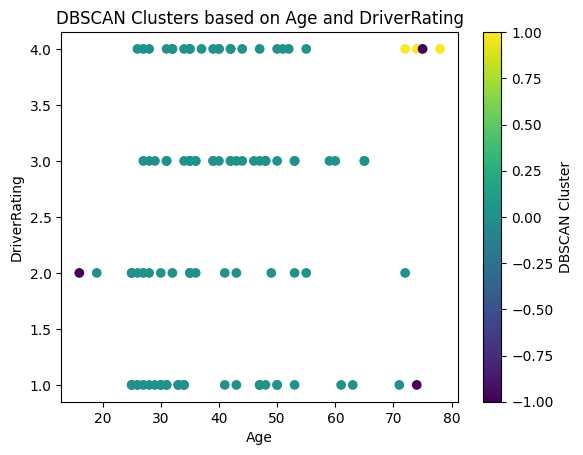

In [6]:
plt.scatter(df_sample['Age'], df_sample['DriverRating'], c=df_sample['DBSCAN_Cluster'])
plt.xlabel('Age')
plt.ylabel('DriverRating')
plt.title('DBSCAN Clusters based on Age and DriverRating')
plt.colorbar(label='DBSCAN Cluster')
plt.show()

## Summary:

### Data Analysis Key Findings
*   A `SyntaxError` in the `plt.scatter` function was identified, caused by the `c=df_sample['DBSCAN_Cluster']` argument being incorrectly placed inside the square brackets for the y-axis data.
*   The error was resolved by repositioning `c=df_sample['DBSCAN_Cluster']` as a separate keyword argument to the `plt.scatter` function.
*   The corrected code executed successfully, generating a scatter plot that visualizes 'Age' against 'DriverRating', with data points colored according to their 'DBSCAN\_Cluster' assignment.

### Insights or Next Steps
*   The successful visualization now allows for inspection and interpretation of the DBSCAN clustering results in the context of 'Age' and 'DriverRating'.
*   Further analysis could involve examining the characteristics of each identified DBSCAN cluster (e.g., average 'Age' and 'DriverRating' per cluster) to gain deeper insights into customer segments or driver behavior.
